In [1]:
import os

PATH = '/kaggle/input/datasets/ruchikamb/mixedwm38-wafer-map-image-dataset/'

os.listdir(path=PATH)

['dataset_info.json', 'colored', 'README.md', 'metadata.csv', 'raw']

First let's load up our metadata, because it has our class information in it.

In [2]:
import pandas as pd
import pathlib

metadata_df = pd.read_csv(filepath_or_buffer=pathlib.Path(PATH, 'metadata.csv'))
metadata_df.shape

(37015, 30)

Are our classes balanced?

In [3]:
metadata_df['class_id'].value_counts().to_frame().T

class_id,C24,C10,C26,C11,C35,C23,C36,C25,C27,C12,...,C34,C20,C22,C6,C1,C19,C8,C21,C9,C7
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,...,1000,1000,1000,1000,1000,1000,1000,1000,866,149


We want to use ResNeXt image embeddings, so let's add some code to get those for us.

In [4]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 160MB/s]


Let's load up our data and add the classes.

In [5]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image

THUMBNAIL_SIZE = (48, 48)

def embed(model, filename: str):
    try:
        with Image.open(fp=filename, mode='r') as image:
            return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)
    except: 
        print(filename)
        return None


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        image.resize(size=THUMBNAIL_SIZE).convert('RGB').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    input_files = list(iglob(pathname=arg))
    input_files = [item for item in input_files if item.endswith('.png')]
    input_files = input_files[:1000]
    result = [pd.Series(data=[tag.replace('_', ' '), basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'])
        for index, input_file in enumerate(tqdm.tqdm(desc=tag, iterable=input_files)) ]
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/colored/*.*' for folder in iglob(PATH + '/*') if isdir(folder) }
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for (key, value) in train_dict.items()]))
train_df = train_df.merge(right=metadata_df[['colored_image_filename', 'class_id']], left_on='name', right_on='colored_image_filename')
train_df = train_df.drop(columns=['colored_image_filename', 'tag']).rename(columns={'class_id': 'tag'})

print('done in {}'.format(arrow.now() - time_start))

colored: 100%|██████████| 1000/1000 [02:21<00:00,  7.04it/s]
raw: 0it [00:00, ?it/s]


done in 0:02:22.316751


Are our classes balanced?

In [6]:
train_df['tag'].value_counts(normalize=True).to_frame().T

tag,C36,C23,C30,C1,C20,C37,C4,C32,C24,C31,...,C5,C21,C33,C14,C35,C17,C6,C12,C34,C7
proportion,0.038,0.036,0.034,0.032,0.032,0.031,0.031,0.031,0.03,0.029,...,0.024,0.023,0.022,0.021,0.021,0.02,0.019,0.019,0.017,0.003


Let's use TSNE to add x/y coordinates based on our image embeddings.

In [7]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1000 samples in 0.011s...
[t-SNE] Computed neighbors for 1000 samples in 0.169s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1000
[t-SNE] Mean sigma: 1.606048
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.595428
[t-SNE] KL divergence after 1000 iterations: 1.086857


Let's make a static plot with a sample of our thumbnails.

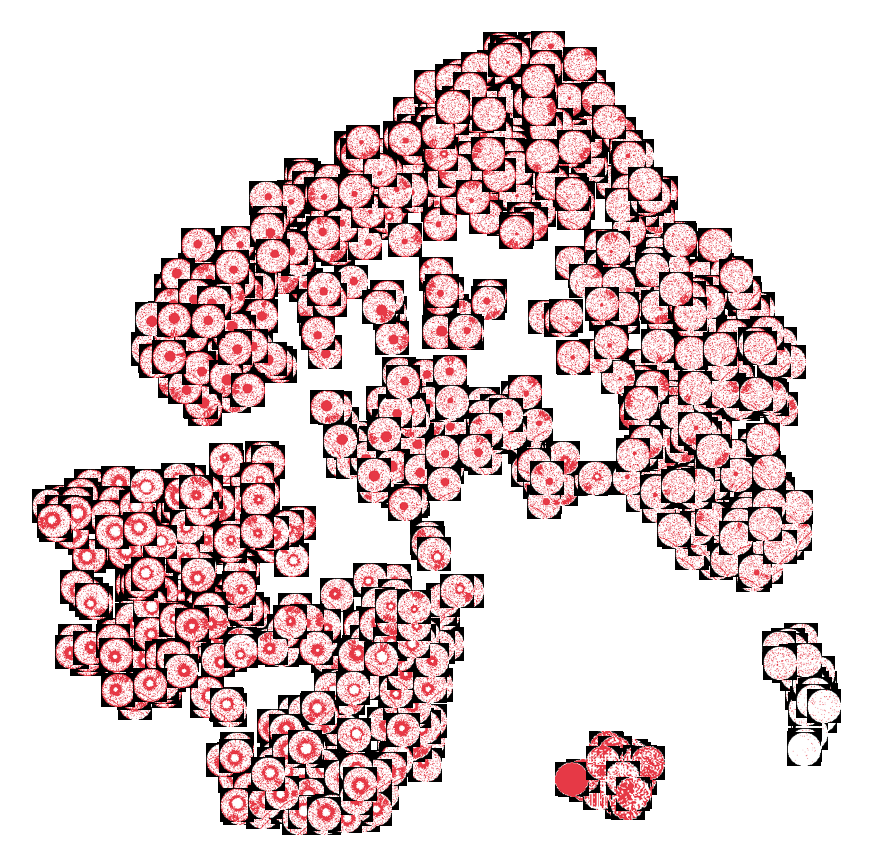

In [8]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image

# we recycled some PNG encoding code above, and we need to postprocess it for using with matplotlib
train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)
plot_df = train_df.sample(n=2500, random_state=2026) if len(train_df) > 2501 else train_df.copy()
fig, ax = plt.subplots(figsize=(11, 11))

for index, row in plot_df.iterrows():
    img_bytes = base64.b64decode(row["PNG"])
    img = Image.open(io.BytesIO(img_bytes))
    imagebox = OffsetImage(img, zoom=0.5)
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)
    ax.add_artist(ab)
ax.scatter(plot_df["x"], plot_df["y"], alpha=0)
ax.axis('off')
plt.show()

What do we see? We see that a LOT of our wafers look very similar. We should have moderate expectations regarding model accuracy unless all those local clusters align with our classes. Let's make an interactive plot and see.

In [9]:
from bokeh.models import ColumnDataSource
from bokeh.models import HoverTool

from bokeh.plotting import figure
from bokeh.plotting import output_notebook
from bokeh.plotting import show
from bokeh.palettes import Turbo256
from bokeh.transform import factor_cmap

output_notebook()

datasource = ColumnDataSource(train_df[['png', 'tag', 'x', 'y']].sample(n=min(len(train_df) - 1, 10000)))
factor_count = max(train_df['tag'].nunique(), 3)
indices = np.linspace(0, len(Turbo256)-1, factor_count, dtype=int)
palette = [Turbo256[index] for index in indices]
mapper = factor_cmap(field_name = 'tag', palette=palette, factors=train_df['tag'].unique().tolist(), start=0, end=factor_count-1, )

plot_figure = figure(title='TSNE projection: wafers', width=1000, height=800, tools=('pan, wheel_zoom, reset'))

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@png' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 18px'>@tag</span>
    </div>
</div>
"""))

plot_figure.scatter(x='x', y='y', source=datasource, line_alpha=0.6, fill_alpha=0.6, size=8, color=mapper)
show(plot_figure)

Loading BokehJS ...

It looks like for the most part the answer is no: our clusters do not really align with our classes. Let's build a model and see what we get.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.2, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 1876 iterations
accuracy: 0.5400
f1: 0.5231
              precision    recall  f1-score   support

          C1       1.00      1.00      1.00         6
         C10       1.00      0.50      0.67         6
         C11       0.50      0.50      0.50         6
         C12       0.40      0.50      0.44         4
         C13       0.44      0.67      0.53         6
         C14       0.33      0.25      0.29         4
         C15       0.50      0.60      0.55         5
         C16       0.50      0.60      0.55         5
         C17       0.00      0.00      0.00         4
         C18       0.20      0.17      0.18         6
         C19       1.00      0.40      0.57         5
          C2       1.00      0.60      0.75         5
         C20       0.55      1.00      0.71         6
         C21       0.43      0.60      0.50         5
         C22       0.75      0.60      0.67         5
         C23       0.38      0.43      0.40         7
         C24       0.50 

What do our model probabilities look like?

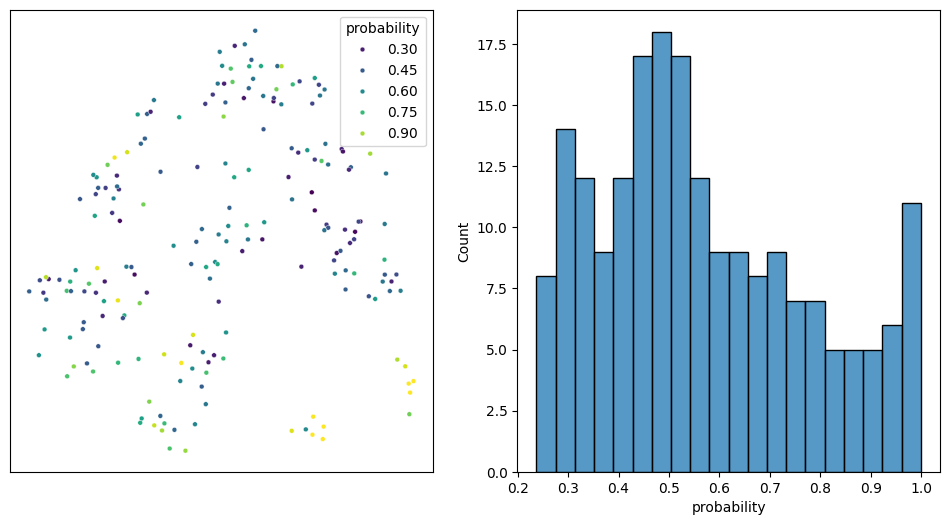

In [11]:
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=12)
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=20)
fig.show()

Our model is mostly not very confident, which is not surprising.